# GTM Visualization with ChemographyKit

This notebook implements Generative Topographic Mapping (GTM) visualization for peptide latent spaces using ChemographyKit.

GTM provides interpretable 2D projections of high-dimensional latent spaces with:
- Smooth, continuous mappings
- Density estimation
- Mode identification
- Region-based sampling capabilities

## Important Notes

**Model Architecture**: This codebase uses a single model class `RNN_VAE` for both VAE and WAE models:
- VAE is configured with `z_regu_loss='kl'` (KL divergence regularization)
- WAE is configured with `z_regu_loss='mmdrf'` (MMD regularization)

**Before Running**: Update the model paths in cell 3 to point to your trained models. The default paths assume models are in `output/vae_batch32/` and `output/wae_batch32/` directories.

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.append('../')

# Resolve project root for notebook execution
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root))


import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# UMAP import (optional)
try:
    import umap
    print("✓ UMAP imported successfully")
except ImportError as e:
    umap = None
    print(f"Warning: UMAP import failed: {e}")
from tqdm.auto import tqdm

# ChemographyKit imports
try:
    from chemographykit import gtm
    from chemographykit.gtm import GTM
    from chemographykit.utils.density import get_density_matrix, density_to_table
    from chemographykit.utils.regression import get_reg_density_matrix, norm_reg_density, reg_density_to_table
    from chemographykit.plots.plotly_landscapes import (
        plotly_smooth_density_landscape,
        plotly_smooth_regression_landscape
    )
    from chemographykit.plots.altair_landscapes import (
        altair_discrete_density_landscape,
        altair_discrete_regression_landscape,
        altair_points_chart
    )
    print("✓ ChemographyKit imported successfully")
except ImportError as e:
    print(f"Warning: ChemographyKit import failed: {e}")
    print("Install with: uv pip install git+https://github.com/Laboratoire-de-Chemoinformatique/ChemographyKit.git")

# Import local modules
from models.model import RNN_VAE  # Single model class for both VAE and WAE
from notebooks.nb_utils import notebook_helpers as nh

# Plotting settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print("✓ All imports successful")


✓ UMAP imported successfully
✓ ChemographyKit imported successfully
✓ All imports successful


In [2]:
# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Model paths - update these to point to your trained models
# Example: output/vae_batch32/model_344000.pt
VAE_MODEL_PATH = project_root / 'output' / 'vae_unlabeled_wandb_batch32/' / 'model_344000.pt'
WAE_MODEL_PATH = project_root / 'output' / 'wae_unlabeled_batch32' / 'model_344000.pt'

# Alternative: use the most recent models automatically
# Uncomment and modify these lines if you want to auto-detect the latest model
# from glob import glob
# vae_models = sorted(glob(str(project_root / 'output' / 'vae*' / 'model_*.pt')))
# wae_models = sorted(glob(str(project_root / 'output' / 'wae*' / 'model_*.pt')))
# VAE_MODEL_PATH = Path(vae_models[-1]) if vae_models else None
# WAE_MODEL_PATH = Path(wae_models[-1]) if wae_models else None

# Data paths
DATA_DIR = project_root / 'data'
RESULTS_DIR = project_root / 'output' / 'sampling_analysis' / 'gtm_analysis'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# GTM parameters - Updated for ChemographyKit API
GTM_CONFIG = {
    'num_nodes': 225,  # 15x15 grid (15*15)
    'num_basis_functions': 100,  # 10x10 basis grid (10*10)
    'basis_width': 1,  # RBF width
    'reg_coeff': 100,  # Regularization coefficient
    'max_iter': 200,  # Maximum EM iterations
    'seed': 42,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"VAE model path: {VAE_MODEL_PATH}")
print(f"VAE model exists: {VAE_MODEL_PATH.exists() if VAE_MODEL_PATH else 'Path not set'}")
print(f"WAE model path: {WAE_MODEL_PATH}")
print(f"WAE model exists: {WAE_MODEL_PATH.exists() if WAE_MODEL_PATH else 'Path not set'}")
print(f"Results directory: {RESULTS_DIR}")

Using device: cuda
VAE model path: /data/aorlov/Programs/WAE_peptides/output/vae_unlabeled_wandb_batch32/model_344000.pt
VAE model exists: True
WAE model path: /data/aorlov/Programs/WAE_peptides/output/wae_unlabeled_batch32/model_344000.pt
WAE model exists: True
Results directory: /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis


## 2. Data Preparation

Load trained models and extract latent representations from both VAE and WAE.

In [3]:
# Load models using the notebook_helpers API
print("Loading models...")

# Load VAE
vae_model, vae_vocab = nh.load_model_and_vocab(
    str(VAE_MODEL_PATH),
    device=str(DEVICE)
)
vae_model.to(DEVICE)
print(f"Loaded VAE model - Latent dim: {vae_model.z_dim}")

# Load WAE  
wae_model, wae_vocab = nh.load_model_and_vocab(
    str(WAE_MODEL_PATH),
    device=str(DEVICE)
)
wae_model.to(DEVICE)
print(f"Loaded WAE model - Latent dim: {wae_model.z_dim}")

print(f"\nVocabulary size: {vae_vocab.size()}")

01/30/2026 04:04:28 PM Loaded Vocabulary.


Loading models...


/data/aorlov/Programs/WAE_peptides/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
01/30/2026 04:04:28 PM Loaded Vocabulary.


Loaded model from /data/aorlov/Programs/WAE_peptides/output/vae_unlabeled_wandb_batch32/model_344000.pt
Vocabulary size: 26
Device: cuda
Loaded VAE model - Latent dim: 100
Loaded model from /data/aorlov/Programs/WAE_peptides/output/wae_unlabeled_batch32/model_344000.pt
Vocabulary size: 26
Device: cuda
Loaded WAE model - Latent dim: 100

Vocabulary size: 26


In [4]:
# Load dataset
# Get the dataset path from cfg
DATA_ROOT = project_root / 'data_processing'
dataset_path = DATA_ROOT / 'allDBs_short_peps_unlabeled.csv'

print(f"Dataset path: {dataset_path}")
print(f"Dataset exists: {dataset_path.exists()}")

# If dataset not found, check alternative locations
if not dataset_path.exists():
    # Try alternative locations
    alt_paths = [
        project_root / 'data' / 'allDBs_short_peps_unlabeled.csv',
        project_root / 'data_processing' / 'data' / 'allDBs_short_peps_unlabeled.csv',
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            dataset_path = alt_path
            print(f"Found dataset at alternative location: {dataset_path}")
            break

Dataset path: /data/aorlov/Programs/WAE_peptides/data_processing/allDBs_short_peps_unlabeled.csv
Dataset exists: True


In [5]:
# Extract latent vectors from models
# Read peptide sequences from the dataset
import pandas as pd

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
    # Take a sample for faster computation (remove .sample() to use full dataset)
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)
    sequences = df_sample['text'].tolist()
    print(f"Loaded {len(sequences)} sequences")
    print(f"Example sequence: {sequences[0]}")
else:
    print("Dataset not found. Creating dummy data for demonstration.")
    # Create some dummy sequences for demonstration
    sequences = ["A L A G L Y", "G L Y A L A", "V A L I L E"] * 100

# Extract latent representations using the notebook_helpers API
# This is the CORRECT way to encode sequences in this codebase
print("\nExtracting VAE latent vectors...")
try:
    vae_encoded = nh.encode_peptides(vae_model, vae_vocab, sequences, sample_q='max')
    z_vae = vae_encoded['z_numpy']
    sequences_vae = sequences
    print(f"✓ Successfully encoded {len(z_vae)} sequences")
    print(f"  Latent shape: {z_vae.shape}")
except Exception as e:
    print(f"✗ Error encoding VAE sequences: {e}")
    import traceback
    traceback.print_exc()
    z_vae = None

print("\nExtracting WAE latent vectors...")
try:
    wae_encoded = nh.encode_peptides(wae_model, wae_vocab, sequences, sample_q='max')
    z_wae = wae_encoded['z_numpy']
    sequences_wae = sequences
    print(f"✓ Successfully encoded {len(z_wae)} sequences")
    print(f"  Latent shape: {z_wae.shape}")
except Exception as e:
    print(f"✗ Error encoding WAE sequences: {e}")
    import traceback
    traceback.print_exc()
    z_wae = None

if z_vae is not None and z_wae is not None:
    print(f"\n✓ Encoding complete!")
    print(f"  VAE latent shape: {z_vae.shape}")
    print(f"  WAE latent shape: {z_wae.shape}")
    print(f"  Number of sequences: {len(sequences_vae)}")
else:
    print("\n✗ Encoding failed. Check error messages above.")

Loaded 10000 sequences
Example sequence: M T R I R R G Y I

Extracting VAE latent vectors...
✓ Successfully encoded 10000 sequences
  Latent shape: (10000, 100)

Extracting WAE latent vectors...
✓ Successfully encoded 10000 sequences
  Latent shape: (10000, 100)

✓ Encoding complete!
  VAE latent shape: (10000, 100)
  WAE latent shape: (10000, 100)
  Number of sequences: 10000


In [6]:
# Standardize latent vectors for GTM
scaler_vae = StandardScaler()
z_vae_scaled = scaler_vae.fit_transform(z_vae)

scaler_wae = StandardScaler()
z_wae_scaled = scaler_wae.fit_transform(z_wae)

print("Latent vector statistics after scaling:")
print(f"VAE - Mean: {z_vae_scaled.mean():.4f}, Std: {z_vae_scaled.std():.4f}")
print(f"WAE - Mean: {z_wae_scaled.mean():.4f}, Std: {z_wae_scaled.std():.4f}")

Latent vector statistics after scaling:
VAE - Mean: -0.0000, Std: 1.0000
WAE - Mean: 0.0000, Std: 1.0000


## 3. Train GTM Models

Train separate GTM models for VAE and WAE latent spaces.

In [7]:
# Train GTM on VAE latent space
print("Training GTM on VAE latent space...")
print(f"Configuration: {GTM_CONFIG}")

# Convert numpy to torch tensor (ChemographyKit requires torch tensors)
z_vae_tensor = torch.from_numpy(z_vae_scaled).to(dtype=torch.float64)

gtm_vae = GTM(
    num_nodes=GTM_CONFIG['num_nodes'],
    num_basis_functions=GTM_CONFIG['num_basis_functions'],
    basis_width=GTM_CONFIG['basis_width'],
    reg_coeff=GTM_CONFIG['reg_coeff'],
    max_iter=GTM_CONFIG['max_iter'],
    seed=GTM_CONFIG['seed'],
    device=GTM_CONFIG['device']
)

gtm_vae.fit(z_vae_tensor)

print("\nGTM training complete!")

# Get log-likelihood by projecting the data
responsibilities_vae, llhs_vae = gtm_vae.project(z_vae_tensor)
avg_log_likelihood = llhs_vae.mean().item()
print(f"Average log-likelihood: {avg_log_likelihood:.4f}")

Training GTM on VAE latent space...
Configuration: {'num_nodes': 225, 'num_basis_functions': 100, 'basis_width': 1, 'reg_coeff': 100, 'max_iter': 200, 'seed': 42, 'device': 'cuda'}


  0%|          | 0/200 [00:00<?, ?it/s]

01/30/2026 04:04:40 PM LLh: -174.31973 deltaLLh: 174.31973 beta: 7.88638
01/30/2026 04:04:40 PM LLh: -101.1289 deltaLLh: 73.19082 beta: 2.36209
01/30/2026 04:04:40 PM LLh: -95.00177 deltaLLh: 6.12714 beta: 2.64156
01/30/2026 04:04:40 PM LLh: -90.68446 deltaLLh: 4.3173 beta: 2.97904
01/30/2026 04:04:40 PM LLh: -88.23414 deltaLLh: 2.45032 beta: 3.18325
01/30/2026 04:04:40 PM LLh: -87.00021 deltaLLh: 1.23393 beta: 3.29342
01/30/2026 04:04:40 PM LLh: -86.3871 deltaLLh: 0.61311 beta: 3.34758
01/30/2026 04:04:40 PM LLh: -86.02317 deltaLLh: 0.36392 beta: 3.37702
01/30/2026 04:04:40 PM LLh: -85.76322 deltaLLh: 0.25996 beta: 3.39687
01/30/2026 04:04:40 PM LLh: -85.53875 deltaLLh: 0.22447 beta: 3.41303
01/30/2026 04:04:40 PM LLh: -85.34473 deltaLLh: 0.19402 beta: 3.42771
01/30/2026 04:04:40 PM LLh: -85.19139 deltaLLh: 0.15334 beta: 3.43935
01/30/2026 04:04:40 PM LLh: -85.05857 deltaLLh: 0.13282 beta: 3.44927
01/30/2026 04:04:40 PM LLh: -84.93281 deltaLLh: 0.12575 beta: 3.45816
01/30/2026 04:04:4


GTM training complete!
Average log-likelihood: -82.8970


In [8]:
# Train GTM on WAE latent space
print("Training GTM on WAE latent space...")

# Convert numpy to torch tensor (ChemographyKit requires torch tensors)
z_wae_tensor = torch.from_numpy(z_wae_scaled).to(dtype=torch.float64)

gtm_wae = GTM(
    num_nodes=GTM_CONFIG['num_nodes'],
    num_basis_functions=GTM_CONFIG['num_basis_functions'],
    basis_width=GTM_CONFIG['basis_width'],
    reg_coeff=GTM_CONFIG['reg_coeff'],
    max_iter=GTM_CONFIG['max_iter'],
    seed=GTM_CONFIG['seed'],
    device=GTM_CONFIG['device']
)

gtm_wae.fit(z_wae_tensor)

print("\nGTM training complete!")

# Get log-likelihood by projecting the data
responsibilities_wae, llhs_wae = gtm_wae.project(z_wae_tensor)
avg_log_likelihood = llhs_wae.mean().item()
print(f"Average log-likelihood: {avg_log_likelihood:.4f}")

Training GTM on WAE latent space...


  0%|          | 0/200 [00:00<?, ?it/s]

01/30/2026 04:04:42 PM LLh: -173.66992 deltaLLh: 173.66992 beta: 2.94815
01/30/2026 04:04:42 PM LLh: -137.57608 deltaLLh: 36.09385 beta: 1.12807
01/30/2026 04:04:42 PM LLh: -136.78487 deltaLLh: 0.79121 beta: 1.15271
01/30/2026 04:04:42 PM LLh: -136.21084 deltaLLh: 0.57403 beta: 1.17665
01/30/2026 04:04:42 PM LLh: -135.7181 deltaLLh: 0.49274 beta: 1.19772
01/30/2026 04:04:42 PM LLh: -135.37801 deltaLLh: 0.34009 beta: 1.21474
01/30/2026 04:04:43 PM LLh: -135.18886 deltaLLh: 0.18915 beta: 1.22499
01/30/2026 04:04:43 PM LLh: -135.07618 deltaLLh: 0.11268 beta: 1.23063
01/30/2026 04:04:43 PM LLh: -134.99709 deltaLLh: 0.07909 beta: 1.23415
01/30/2026 04:04:43 PM LLh: -134.93687 deltaLLh: 0.06022 beta: 1.23668
01/30/2026 04:04:43 PM LLh: -134.88982 deltaLLh: 0.04704 beta: 1.23859
01/30/2026 04:04:43 PM LLh: -134.85154 deltaLLh: 0.03828 beta: 1.24008
01/30/2026 04:04:43 PM LLh: -134.81959 deltaLLh: 0.03196 beta: 1.24131
01/30/2026 04:04:43 PM LLh: -134.7926 deltaLLh: 0.02698 beta: 1.24235
01/30


GTM training complete!
Average log-likelihood: -134.3624


In [9]:
# Project data points to GTM space (get responsibilities)
print("Projecting data to GTM space...")

# Get mode (MAP estimate) for each point - transform returns latent coordinates
gtm_coords_vae = gtm_vae.transform(z_vae_tensor).cpu().numpy()
gtm_coords_wae = gtm_wae.transform(z_wae_tensor).cpu().numpy()

# Convert responsibilities to numpy (already computed during training)
responsibilities_vae = responsibilities_vae.cpu().numpy()
responsibilities_wae = responsibilities_wae.cpu().numpy()

print(f"VAE GTM coordinates shape: {gtm_coords_vae.shape}")
print(f"WAE GTM coordinates shape: {gtm_coords_wae.shape}")
print(f"VAE Responsibilities shape: {responsibilities_vae.shape}")
print(f"WAE Responsibilities shape: {responsibilities_wae.shape}")

Projecting data to GTM space...
VAE GTM coordinates shape: (10000, 2)
WAE GTM coordinates shape: (10000, 2)
VAE Responsibilities shape: (10000, 225)
WAE Responsibilities shape: (10000, 225)


## 4. Visualize GTM Maps

Create 2D projections colored by various properties.

In [10]:
# Create DataFrame for visualization
df_vae = pd.DataFrame({
    'gtm_x': gtm_coords_vae[:, 0],
    'gtm_y': gtm_coords_vae[:, 1],
    'model': 'VAE'
})

df_wae = pd.DataFrame({
    'gtm_x': gtm_coords_wae[:, 0],
    'gtm_y': gtm_coords_wae[:, 1],
    'model': 'WAE'
})

# Add sequences if available
if sequences_vae:
    df_vae['sequence'] = sequences_vae
if sequences_wae:
    df_wae['sequence'] = sequences_wae

print("Created visualization DataFrames")
print(f"VAE points: {len(df_vae)}")
print(f"WAE points: {len(df_wae)}")

Created visualization DataFrames
VAE points: 10000
WAE points: 10000


In [11]:
# Compute peptide properties for coloring
def compute_peptide_properties(sequences):
    """Compute basic peptide properties."""
    properties = {
        'length': [],
        'hydrophobicity': [],
        'charge': []
    }
    
    # Simplified hydrophobicity scale
    hydrophobic_aas = set('AILMFWYV')
    charged_positive = set('KR')
    charged_negative = set('DE')
    
    for seq in sequences:
        if not seq:
            properties['length'].append(0)
            properties['hydrophobicity'].append(0)
            properties['charge'].append(0)
            continue
        
        properties['length'].append(len(seq))
        
        # Fraction of hydrophobic residues
        hydrophobic_count = sum(1 for aa in seq if aa in hydrophobic_aas)
        properties['hydrophobicity'].append(hydrophobic_count / len(seq) if len(seq) > 0 else 0)
        
        # Net charge
        pos_charge = sum(1 for aa in seq if aa in charged_positive)
        neg_charge = sum(1 for aa in seq if aa in charged_negative)
        properties['charge'].append(pos_charge - neg_charge)
    
    return properties

if sequences_vae:
    props_vae = compute_peptide_properties(sequences_vae)
    for key, values in props_vae.items():
        df_vae[key] = values

if sequences_wae:
    props_wae = compute_peptide_properties(sequences_wae)
    for key, values in props_wae.items():
        df_wae[key] = values

print("Computed peptide properties:")
print(df_vae[['length', 'hydrophobicity', 'charge']].describe())

Computed peptide properties:
             length  hydrophobicity        charge
count  10000.000000    10000.000000  10000.000000
mean      37.064000        0.220458      0.734200
std        9.846096        0.072119      2.495551
min       11.000000        0.000000    -18.000000
25%       29.000000        0.172414     -1.000000
50%       39.000000        0.219512      1.000000
75%       45.000000        0.265306      2.000000
max       49.000000        0.526316     18.000000


Creating ChemographyKit landscape visualizations for VAE...
Saved interactive plot to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_vae_properties.html


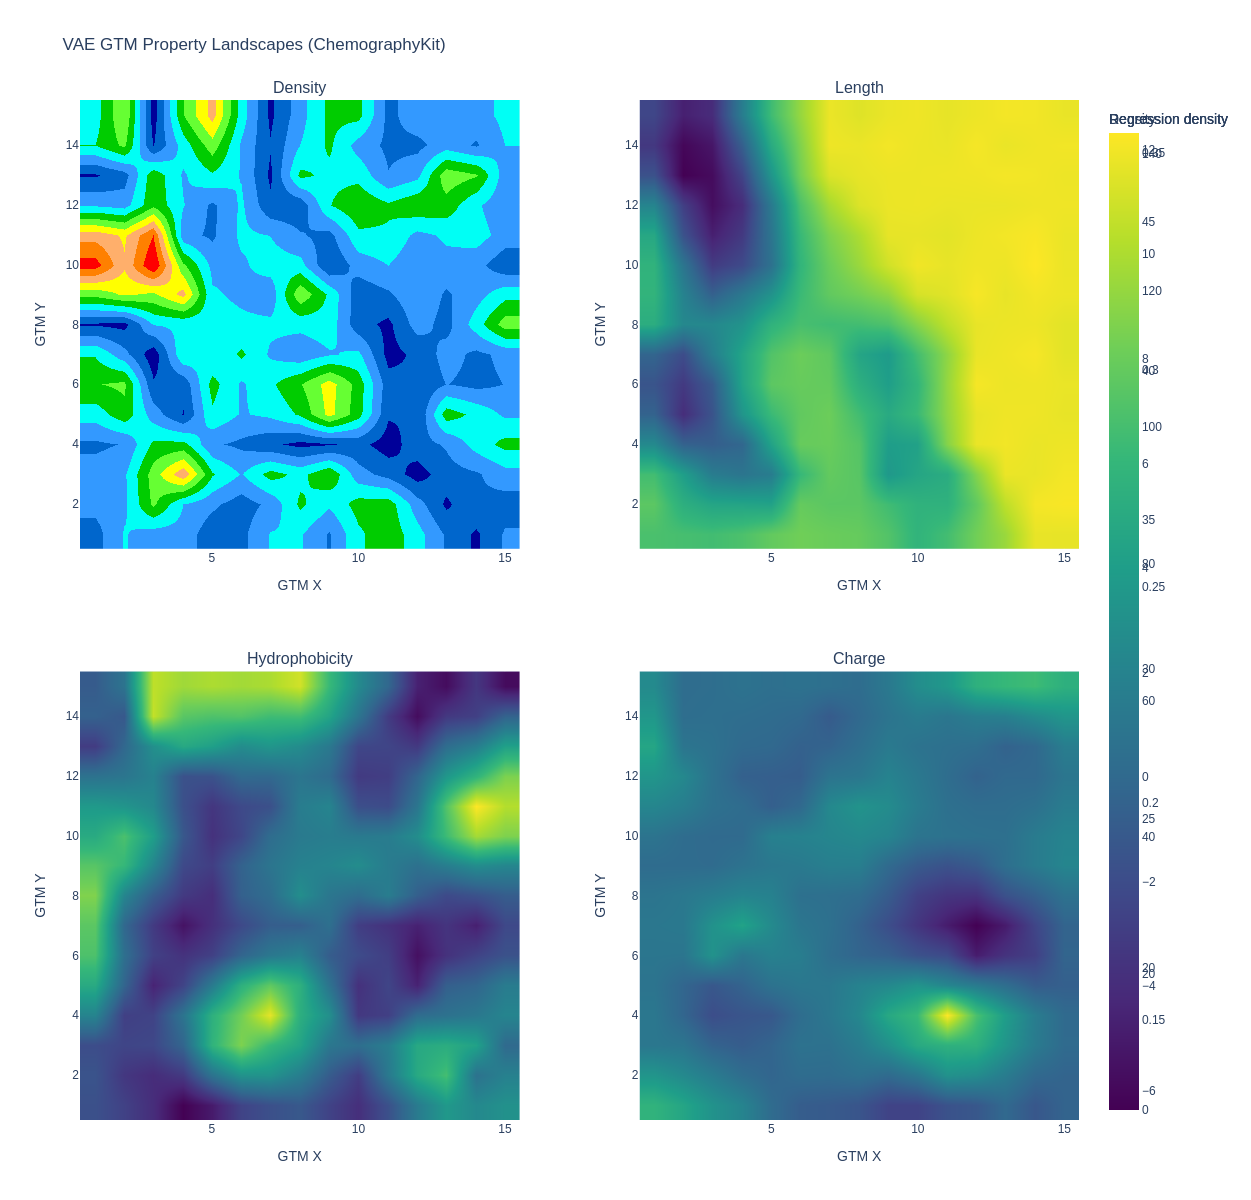

Saved density landscape to gtm_vae_density_landscape.html
Saved length landscape to gtm_vae_length_landscape.html
Saved hydrophobicity landscape to gtm_vae_hydrophobicity_landscape.html
Saved charge landscape to gtm_vae_charge_landscape.html


In [12]:
# Interactive GTM visualization with Plotly - VAE using ChemographyKit landscapes

print("Creating ChemographyKit landscape visualizations for VAE...")

# Compute density using ChemographyKit utilities
# Note: responsibilities should have shape (n_nodes, n_samples)
density_vae_vec = get_density_matrix(responsibilities_vae)
density_table_vae = density_to_table(
    density_vae_vec,
    node_threshold=0.01,
    output_csv_file=None
)

# Create smooth density landscape
fig_density_vae = plotly_smooth_density_landscape(
    density_table_vae,
    node_threshold=0.01,
    use_smooth=True,
    title="VAE GTM Density Landscape",
    width=800,
    height=800,
    background_color="white"
)

# Create regression landscapes for peptide properties
properties = ['length', 'hydrophobicity', 'charge']
figs_vae = {'density': fig_density_vae}

for prop in properties:
    if prop in df_vae.columns:
        # Compute regression density
        reg_values = df_vae[prop].values
        density, reg_density = get_reg_density_matrix(responsibilities_vae, list(reg_values))

        # Normalize by overall density
        #reg_density_norm = norm_reg_density(reg_density, density_vae_vec)

        # Convert to table
        reg_table = reg_density_to_table(
            density,
            reg_density,
            node_threshold=0.01,
            output_csv_file=None
        )

        # Create smooth regression landscape
        fig = plotly_smooth_regression_landscape(
            reg_table,
            colorset='Viridis',
            title=f"VAE GTM {prop.capitalize()} Landscape",
            width=800,
            height=800,
            background_color="white",
            use_smooth=True
        )

        figs_vae[prop] = fig

# Create combined figure with subplots
fig_combined_vae = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Density', 'Length', 'Hydrophobicity', 'Charge'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}],
           [{'type': 'heatmap'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# Add landscapes to subplots
landscape_positions = [
    ('density', 1, 1),
    ('length', 1, 2),
    ('hydrophobicity', 2, 1),
    ('charge', 2, 2)
]

for prop, row, col in landscape_positions:
    if prop in figs_vae:
        # Extract the heatmap trace from the figure
        for trace in figs_vae[prop].data:
            fig_combined_vae.add_trace(trace, row=row, col=col)

fig_combined_vae.update_layout(
    title_text="VAE GTM Property Landscapes (ChemographyKit)",
    height=1200,
    width=1200,
    showlegend=False
)

# Update axes
for i in range(1, 3):
    for j in range(1, 3):
        fig_combined_vae.update_xaxes(title_text="GTM X", row=i, col=j)
        fig_combined_vae.update_yaxes(title_text="GTM Y", row=i, col=j)

# Save
output_path_vae = RESULTS_DIR / 'gtm_vae_properties.html'
fig_combined_vae.write_html(str(output_path_vae))
print(f"Saved interactive plot to {output_path_vae}")

# Show
fig_combined_vae.show()

# Save individual landscapes for detailed viewing
for prop, fig in figs_vae.items():
    fig.write_html(str(RESULTS_DIR / f'gtm_vae_{prop}_landscape.html'))
    print(f"Saved {prop} landscape to gtm_vae_{prop}_landscape.html")


Creating ChemographyKit landscape visualizations for WAE...
Saved interactive plot to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_wae_properties.html


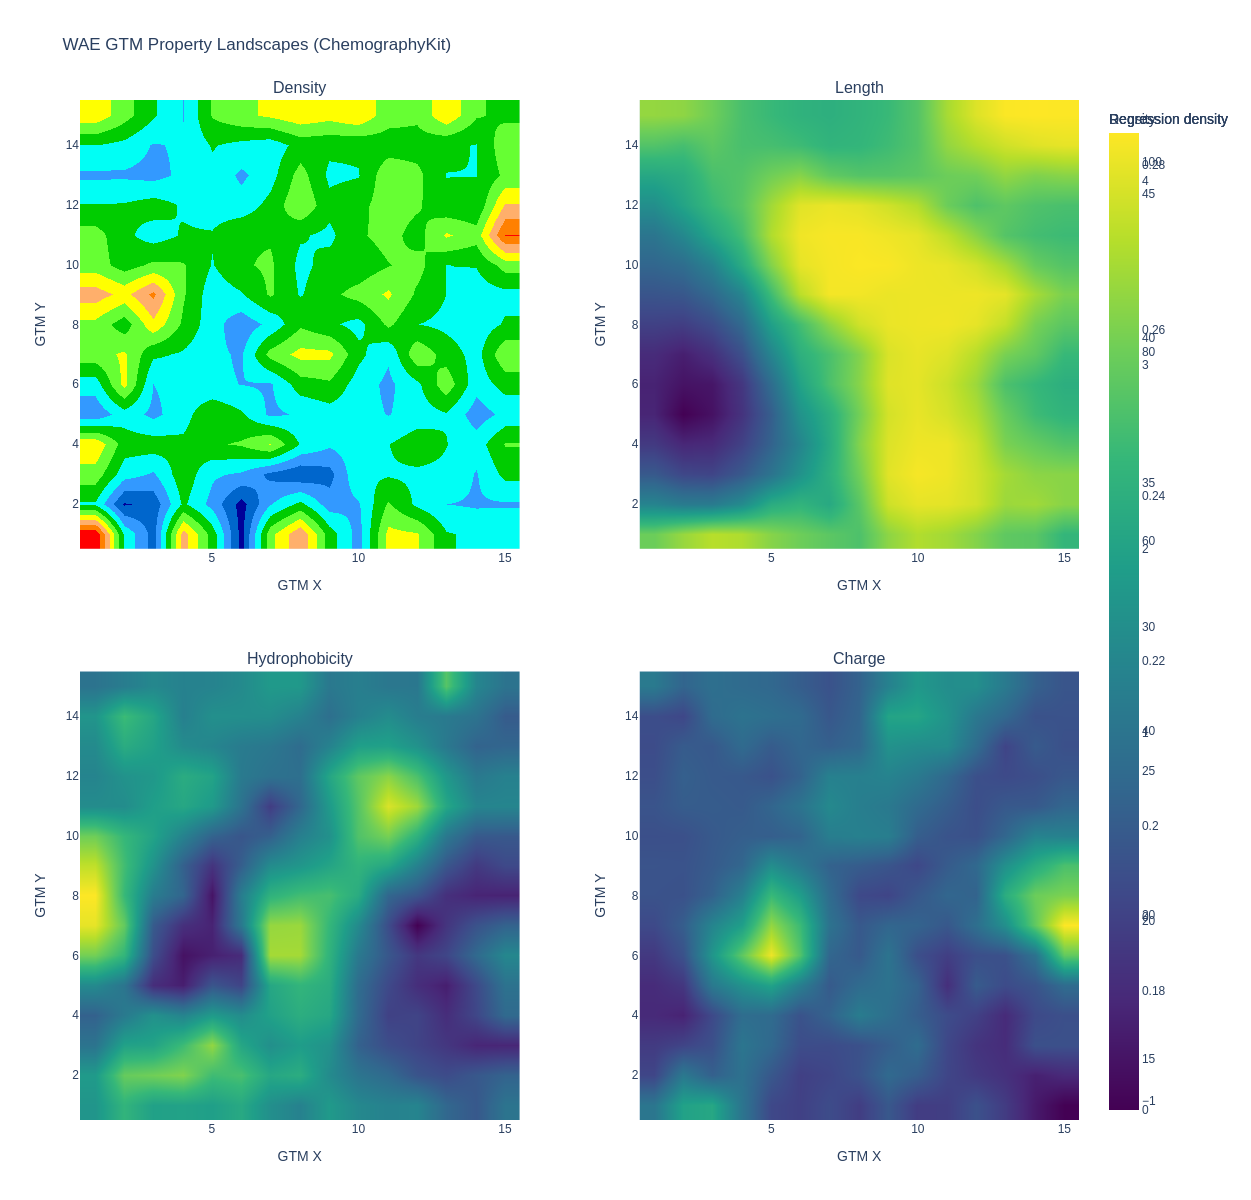

Saved density landscape to gtm_wae_density_landscape.html
Saved length landscape to gtm_wae_length_landscape.html
Saved hydrophobicity landscape to gtm_wae_hydrophobicity_landscape.html
Saved charge landscape to gtm_wae_charge_landscape.html


In [13]:
# Interactive GTM visualization with Plotly - WAE using ChemographyKit landscapes

print("Creating ChemographyKit landscape visualizations for WAE...")

# Compute density using ChemographyKit utilities
density_wae_vec = get_density_matrix(responsibilities_wae)
density_table_wae = density_to_table(
    density_wae_vec,
    node_threshold=0.01,
    output_csv_file=None
)

# Create smooth density landscape
fig_density_wae = plotly_smooth_density_landscape(
    density_table_wae,
    node_threshold=0.01,
    use_smooth=True,
    title="WAE GTM Density Landscape",
    width=800,
    height=800,
    background_color="white"
)

# Create regression landscapes for peptide properties
figs_wae = {'density': fig_density_wae}

for prop in properties:
    if prop in df_wae.columns:
        # Compute regression density
        reg_values = df_wae[prop].values
        density, reg_density = get_reg_density_matrix(responsibilities_wae, list(reg_values))

        # Convert to table
        reg_table = reg_density_to_table(
            density,
            reg_density,
            node_threshold=0.01,
            output_csv_file=None
        )

        # Create smooth regression landscape
        fig = plotly_smooth_regression_landscape(
            reg_table,
            colorset='Viridis',
            title=f"WAE GTM {prop.capitalize()} Landscape",
            width=800,
            height=800,
            background_color="white",
            use_smooth=True
        )

        figs_wae[prop] = fig

# Create combined figure with subplots
fig_combined_wae = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Density', 'Length', 'Hydrophobicity', 'Charge'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}],
           [{'type': 'heatmap'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# Add landscapes to subplots
for prop, row, col in landscape_positions:
    if prop in figs_wae:
        for trace in figs_wae[prop].data:
            fig_combined_wae.add_trace(trace, row=row, col=col)

fig_combined_wae.update_layout(
    title_text="WAE GTM Property Landscapes (ChemographyKit)",
    height=1200,
    width=1200,
    showlegend=False
)

# Update axes
for i in range(1, 3):
    for j in range(1, 3):
        fig_combined_wae.update_xaxes(title_text="GTM X", row=i, col=j)
        fig_combined_wae.update_yaxes(title_text="GTM Y", row=i, col=j)

# Save
output_path_wae = RESULTS_DIR / 'gtm_wae_properties.html'
fig_combined_wae.write_html(str(output_path_wae))
print(f"Saved interactive plot to {output_path_wae}")

# Show
fig_combined_wae.show()

# Save individual landscapes
for prop, fig in figs_wae.items():
    fig.write_html(str(RESULTS_DIR / f'gtm_wae_{prop}_landscape.html'))
    print(f"Saved {prop} landscape to gtm_wae_{prop}_landscape.html")


## 5. Landscape Analysis

Analyze density maps, responsibility patterns, and identify modes in the GTM space.

In [14]:
# Compute density map (number of points per GTM node) using ChemographyKit

print("Computing density maps using ChemographyKit utilities...")

# Compute density using ChemographyKit (already done in cells 16-17)
# This keeps the variables for backward compatibility
# Note: responsibilities shape should be (n_nodes, n_samples) for get_density_matrix

# Reshape to grid for compatibility with existing code
k_vae = int(np.sqrt(len(density_vae_vec)))
k_wae = int(np.sqrt(len(density_wae_vec)))

density_vae = density_vae_vec.reshape(k_vae, k_vae)
density_wae = density_wae_vec.reshape(k_wae, k_wae)

print(f"VAE density range: {density_vae.min():.2f} - {density_vae.max():.2f}")
print(f"WAE density range: {density_wae.min():.2f} - {density_wae.max():.2f}")
print(f"VAE density shape: {density_vae.shape}")
print(f"WAE density shape: {density_wae.shape}")


Computing density maps using ChemographyKit utilities...
VAE density range: 4.82 - 143.11
WAE density range: 6.17 - 103.03
VAE density shape: (15, 15)
WAE density shape: (15, 15)


Creating publication-quality density landscapes...
Saved Altair density landscapes to:
  - /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_density_vae_altair.html
  - /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_density_wae_altair.html
VAE Density Landscape (Altair):


alt.Chart(...)

WAE Density Landscape (Altair):


alt.Chart(...)

Saved density comparison to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_density_comparison.html


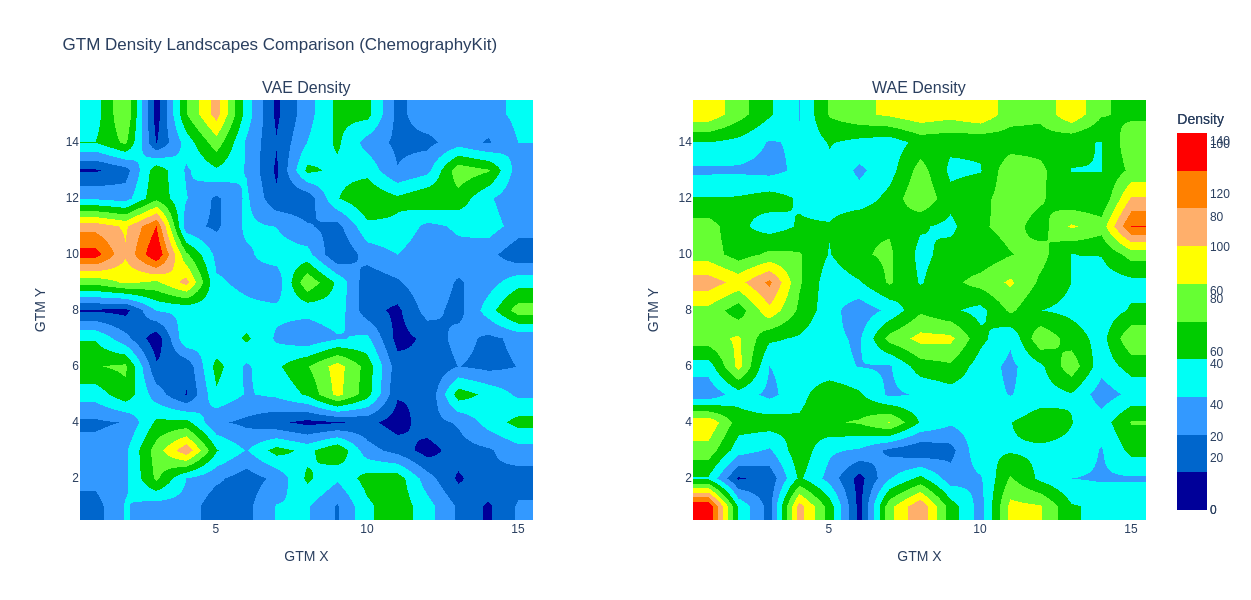

In [15]:
# Visualize density maps using ChemographyKit landscapes

print("Creating publication-quality density landscapes...")

# Create Altair static landscapes for publication
chart_vae = altair_discrete_density_landscape(
    density_table_vae,
    title="VAE GTM Density Landscape"
)

chart_wae = altair_discrete_density_landscape(
    density_table_wae,
    title="WAE GTM Density Landscape"
)

# Save as HTML
altair_vae_path = RESULTS_DIR / 'gtm_density_vae_altair.html'
altair_wae_path = RESULTS_DIR / 'gtm_density_wae_altair.html'

chart_vae.save(str(altair_vae_path))
chart_wae.save(str(altair_wae_path))

print(f"Saved Altair density landscapes to:")
print(f"  - {altair_vae_path}")
print(f"  - {altair_wae_path}")

# Display (works in Jupyter)
from IPython.display import display
print("VAE Density Landscape (Altair):")
display(chart_vae)

print("WAE Density Landscape (Altair):")
display(chart_wae)

# Also create interactive Plotly versions side-by-side
fig_comparison = make_subplots(
    rows=1, cols=2,
    subplot_titles=('VAE Density', 'WAE Density'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.15
)

# Add VAE density
for trace in fig_density_vae.data:
    fig_comparison.add_trace(trace, row=1, col=1)

# Add WAE density
for trace in fig_density_wae.data:
    fig_comparison.add_trace(trace, row=1, col=2)

fig_comparison.update_layout(
    title_text="GTM Density Landscapes Comparison (ChemographyKit)",
    height=600,
    width=1400,
    showlegend=False
)

# Update axes
fig_comparison.update_xaxes(title_text="GTM X", row=1, col=1)
fig_comparison.update_yaxes(title_text="GTM Y", row=1, col=1)
fig_comparison.update_xaxes(title_text="GTM X", row=1, col=2)
fig_comparison.update_yaxes(title_text="GTM Y", row=1, col=2)

# Save comparison
comparison_path = RESULTS_DIR / 'gtm_density_comparison.html'
fig_comparison.write_html(str(comparison_path))
print(f"Saved density comparison to {comparison_path}")

# Show
fig_comparison.show()


In [16]:
# Identify modes (high-density regions)
def identify_modes(density_grid, threshold_percentile=90):
    """Identify high-density modes in GTM space."""
    threshold = np.percentile(density_grid, threshold_percentile)
    modes = density_grid > threshold
    
    # Get coordinates of modes
    mode_coords = np.argwhere(modes)
    mode_densities = [density_grid[coord[0], coord[1]] for coord in mode_coords]
    
    return mode_coords, mode_densities, threshold

modes_vae, densities_vae, threshold_vae = identify_modes(density_vae)
modes_wae, densities_wae, threshold_wae = identify_modes(density_wae)

print(f"VAE: Found {len(modes_vae)} modes (threshold: {threshold_vae:.2f})")
print(f"WAE: Found {len(modes_wae)} modes (threshold: {threshold_wae:.2f})")

VAE: Found 23 modes (threshold: 74.39)
WAE: Found 23 modes (threshold: 63.24)


Creating enhanced mode visualizations with landscape backgrounds...
Saved mode visualizations to:
  - /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_modes_vae.html
  - /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_modes_wae.html


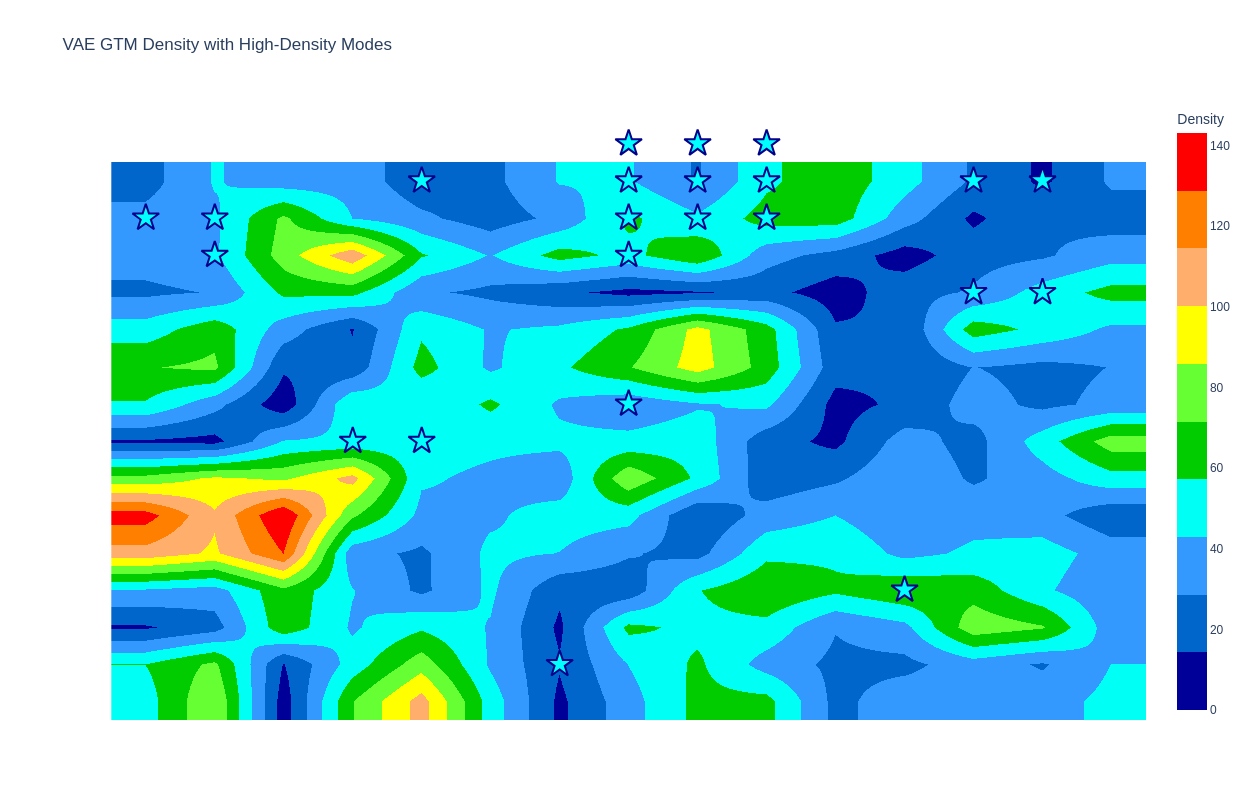

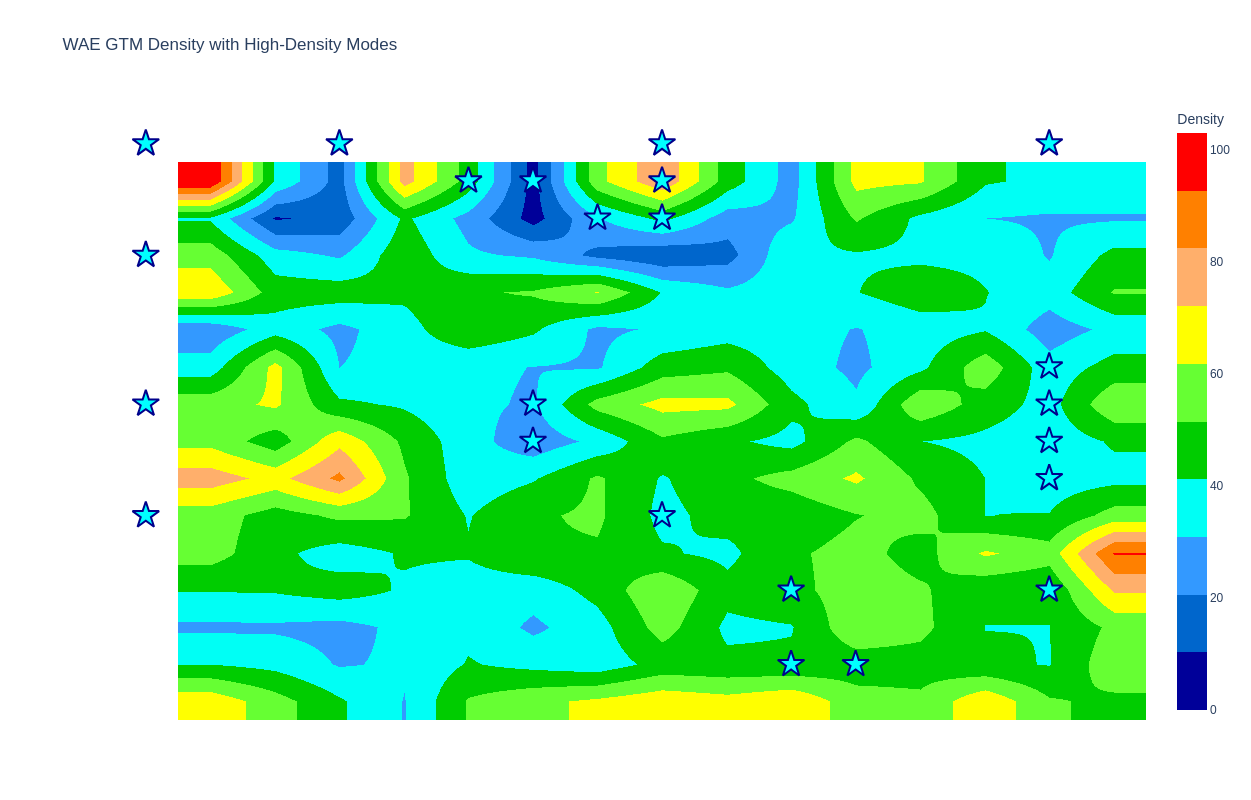

Saved modes comparison to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_modes_comparison.html


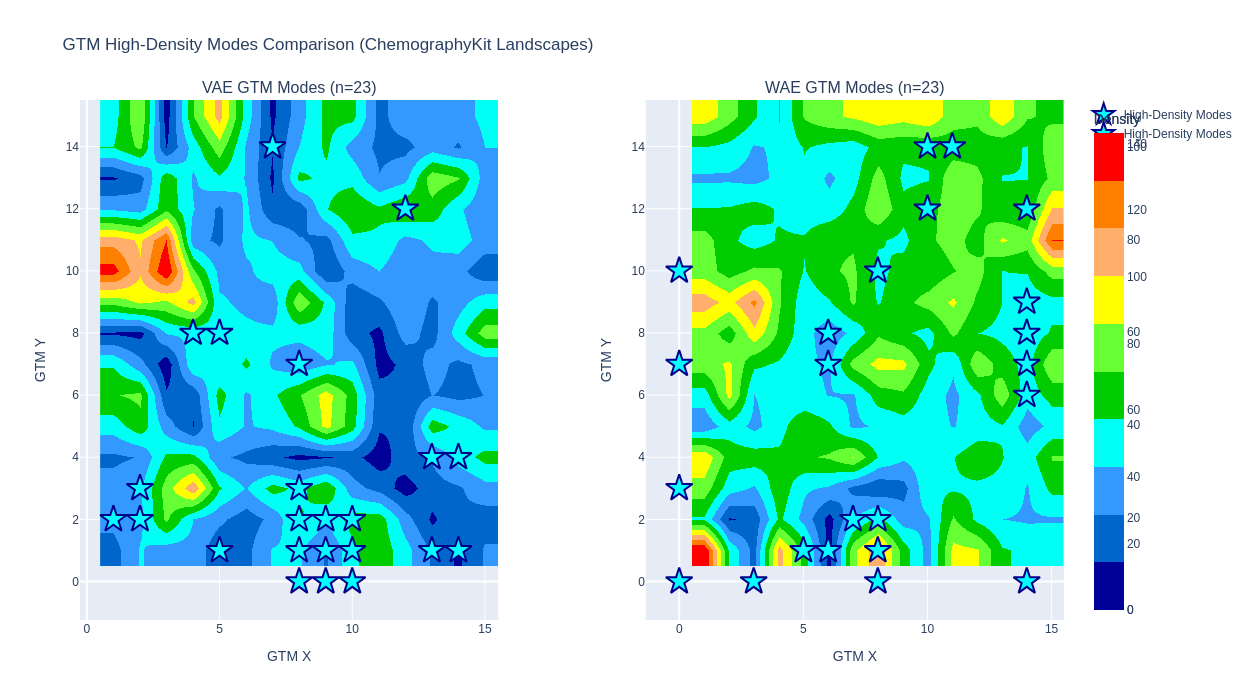

In [17]:
# Visualize modes on density landscapes using ChemographyKit

print("Creating enhanced mode visualizations with landscape backgrounds...")

# Create smooth density landscapes as base
fig_modes_vae = plotly_smooth_density_landscape(
    density_table_vae,
    node_threshold=0.01,
    use_smooth=True,
    title="VAE GTM Density with High-Density Modes",
    width=900,
    height=800,
    background_color="white"
)

fig_modes_wae = plotly_smooth_density_landscape(
    density_table_wae,
    node_threshold=0.01,
    use_smooth=True,
    title="WAE GTM Density with High-Density Modes",
    width=900,
    height=800,
    background_color="white"
)

# Convert mode grid coordinates to continuous GTM coordinates
# modes_vae and modes_wae have shape (n_modes, 2) with grid indices
# We need to convert them to GTM x,y coordinates

def grid_to_gtm_coords(modes, k):
    """Convert grid indices to GTM continuous coordinates"""
    # Grid indices are (row, col), GTM coords are (x, y)
    # Normalize to [0, k-1] range
    gtm_coords = modes.copy().astype(float)
    return gtm_coords

modes_vae_gtm = grid_to_gtm_coords(modes_vae, k_vae)
modes_wae_gtm = grid_to_gtm_coords(modes_wae, k_wae)

# Add mode markers to VAE plot
fig_modes_vae.add_trace(
    go.Scatter(
        x=modes_vae_gtm[:, 1],  # col -> x
        y=modes_vae_gtm[:, 0],  # row -> y
        mode='markers',
        marker=dict(
            size=20,
            color='cyan',
            symbol='star',
            line=dict(color='darkblue', width=2)
        ),
        name='High-Density Modes',
        hovertemplate='Mode %{text}<br>x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>',
        text=[f'{i+1}' for i in range(len(modes_vae))]
    )
)

# Add mode markers to WAE plot
fig_modes_wae.add_trace(
    go.Scatter(
        x=modes_wae_gtm[:, 1],
        y=modes_wae_gtm[:, 0],
        mode='markers',
        marker=dict(
            size=20,
            color='cyan',
            symbol='star',
            line=dict(color='darkblue', width=2)
        ),
        name='High-Density Modes',
        hovertemplate='Mode %{text}<br>x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>',
        text=[f'{i+1}' for i in range(len(modes_wae))]
    )
)

# Save
vae_modes_path = RESULTS_DIR / 'gtm_modes_vae.html'
wae_modes_path = RESULTS_DIR / 'gtm_modes_wae.html'

fig_modes_vae.write_html(str(vae_modes_path))
fig_modes_wae.write_html(str(wae_modes_path))

print(f"Saved mode visualizations to:")
print(f"  - {vae_modes_path}")
print(f"  - {wae_modes_path}")

# Show
fig_modes_vae.show()
fig_modes_wae.show()

# Create side-by-side comparison
fig_modes_comparison = make_subplots(
    rows=1, cols=2,
    subplot_titles=(f'VAE GTM Modes (n={len(modes_vae)})', f'WAE GTM Modes (n={len(modes_wae)})'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.15
)

# Add VAE
for trace in fig_modes_vae.data:
    fig_modes_comparison.add_trace(trace, row=1, col=1)

# Add WAE
for trace in fig_modes_wae.data:
    fig_modes_comparison.add_trace(trace, row=1, col=2)

fig_modes_comparison.update_layout(
    title_text="GTM High-Density Modes Comparison (ChemographyKit Landscapes)",
    height=700,
    width=1600,
    showlegend=True
)

# Update axes
fig_modes_comparison.update_xaxes(title_text="GTM X", row=1, col=1)
fig_modes_comparison.update_yaxes(title_text="GTM Y", row=1, col=1)
fig_modes_comparison.update_xaxes(title_text="GTM X", row=1, col=2)
fig_modes_comparison.update_yaxes(title_text="GTM Y", row=1, col=2)

# Save
comparison_modes_path = RESULTS_DIR / 'gtm_modes_comparison.html'
fig_modes_comparison.write_html(str(comparison_modes_path))
print(f"Saved modes comparison to {comparison_modes_path}")

fig_modes_comparison.show()


In [18]:
# Analyze responsibility patterns
def analyze_responsibilities(responsibilities):
    """Analyze responsibility distribution statistics."""
    # Maximum responsibility per point
    max_resp = responsibilities.max(axis=1)
    
    # Effective number of nodes per point (participation ratio)
    effective_nodes = 1.0 / (responsibilities ** 2).sum(axis=1)
    
    stats = {
        'max_resp_mean': max_resp.mean(),
        'max_resp_std': max_resp.std(),
        'effective_nodes_mean': effective_nodes.mean(),
        'effective_nodes_std': effective_nodes.std()
    }
    
    return stats, max_resp, effective_nodes

stats_vae, max_resp_vae, eff_nodes_vae = analyze_responsibilities(responsibilities_vae)
stats_wae, max_resp_wae, eff_nodes_wae = analyze_responsibilities(responsibilities_wae)

print("\nVAE Responsibility Statistics:")
for key, value in stats_vae.items():
    print(f"  {key}: {value:.4f}")

print("\nWAE Responsibility Statistics:")
for key, value in stats_wae.items():
    print(f"  {key}: {value:.4f}")


VAE Responsibility Statistics:
  max_resp_mean: 0.9249
  max_resp_std: 0.1341
  effective_nodes_mean: 1.1881
  effective_nodes_std: 0.3628

WAE Responsibility Statistics:
  max_resp_mean: 0.4880
  max_resp_std: 0.1726
  effective_nodes_mean: 3.6362
  effective_nodes_std: 2.1036


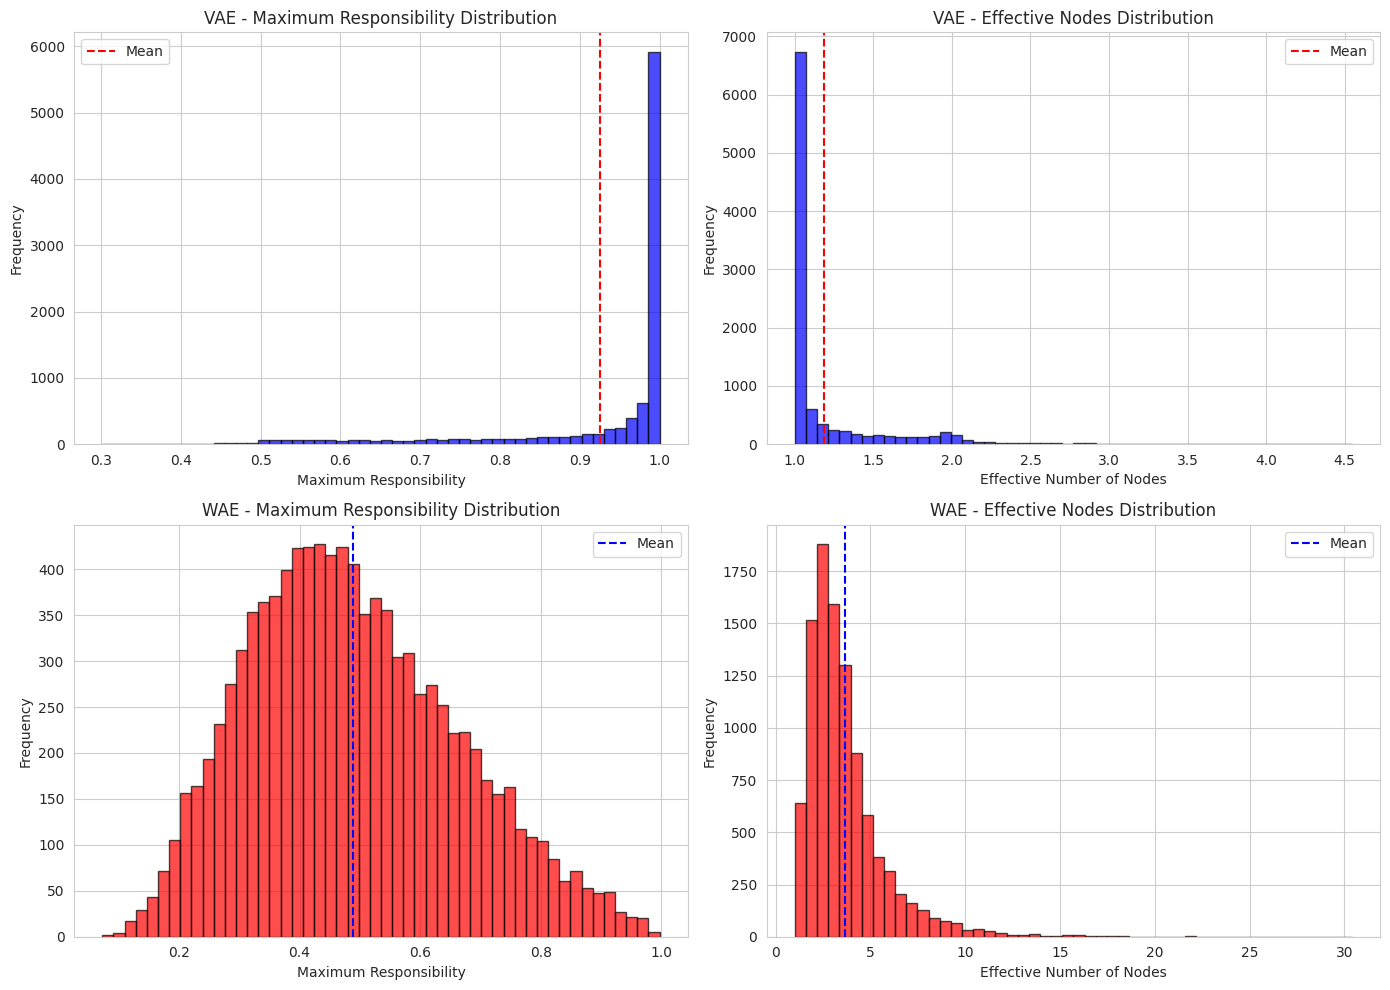

Saved responsibility analysis to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_responsibility_analysis.png


In [19]:
# Plot responsibility distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VAE - Max responsibility
axes[0, 0].hist(max_resp_vae, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Maximum Responsibility')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('VAE - Maximum Responsibility Distribution')
axes[0, 0].axvline(max_resp_vae.mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# VAE - Effective nodes
axes[0, 1].hist(eff_nodes_vae, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].set_xlabel('Effective Number of Nodes')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('VAE - Effective Nodes Distribution')
axes[0, 1].axvline(eff_nodes_vae.mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# WAE - Max responsibility
axes[1, 0].hist(max_resp_wae, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1, 0].set_xlabel('Maximum Responsibility')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('WAE - Maximum Responsibility Distribution')
axes[1, 0].axvline(max_resp_wae.mean(), color='blue', linestyle='--', label='Mean')
axes[1, 0].legend()

# WAE - Effective nodes
axes[1, 1].hist(eff_nodes_wae, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1, 1].set_xlabel('Effective Number of Nodes')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('WAE - Effective Nodes Distribution')
axes[1, 1].axvline(eff_nodes_wae.mean(), color='blue', linestyle='--', label='Mean')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gtm_responsibility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved responsibility analysis to {RESULTS_DIR / 'gtm_responsibility_analysis.png'}")

## 6. Region Sampling

Generate peptides from specific regions of the GTM space.

In [20]:
def sample_from_gtm_region(gtm_model, scaler, decoder_model, vocab, region_coords, z_scaled, responsibilities, n_samples=10):
    """Sample peptides from specific GTM region.
    
    Args:
        gtm_model: Trained GTM model
        scaler: StandardScaler used for latent vectors
        decoder_model: VAE/WAE decoder
        vocab: Vocabulary for decoding
        region_coords: List of (y, x) coordinates in GTM grid
        z_scaled: Scaled latent vectors (original data)
        responsibilities: Responsibility matrix (num_samples, num_nodes)
        n_samples: Number of samples per coordinate
    """
    samples = []
    grid_size = int(np.sqrt(GTM_CONFIG['num_nodes']))
    
    for coord in region_coords:
        # Get the node index from grid coordinates
        node_idx = coord[0] * grid_size + coord[1]
        
        # Find data points that are close to this node
        node_responsibilities = responsibilities[:, node_idx]
        
        # Get indices of points with high responsibility for this node
        top_indices = np.argsort(node_responsibilities)[-50:]  # Top 50 points
        
        # Sample from the high-dimensional latent vectors of these points
        for _ in range(n_samples):
            # Randomly select one of the high-responsibility points
            idx = np.random.choice(top_indices)
            z_sample = z_scaled[idx] + np.random.randn(z_scaled.shape[1]) * 0.1
            
            # Inverse transform scaling
            z_sample = scaler.inverse_transform(z_sample.reshape(1, -1))
            
            # Decode to peptide sequence using sample_peptides
            try:
                z_tensor = torch.FloatTensor(z_sample).to(DEVICE)
                result = nh.sample_peptides(
                    decoder_model, 
                    vocab, 
                    n_samples=1,
                    z=z_tensor,
                    sample_mode='categorical',
                    temperature=1.0
                )
                samples.append(result['sequences'][0])
            except Exception as e:
                print(f"Error decoding: {e}")
                samples.append("ERROR")
    
    return samples

print("Region sampling function defined")
print("Uses notebook_helpers.sample_peptides() for proper sequence generation")

Region sampling function defined
Uses notebook_helpers.sample_peptides() for proper sequence generation


In [21]:
# Sample from high-density modes
print("Sampling from VAE high-density modes...")
vae_mode_samples = sample_from_gtm_region(
    gtm_vae, 
    scaler_vae, 
    vae_model,
    vae_vocab,
    modes_vae[:5],  # Top 5 modes
    z_vae_scaled,
    responsibilities_vae,
    n_samples=5
)

print("\nSampling from WAE high-density modes...")
wae_mode_samples = sample_from_gtm_region(
    gtm_wae,
    scaler_wae,
    wae_model,
    wae_vocab,
    modes_wae[:5],
    z_wae_scaled,
    responsibilities_wae,
    n_samples=5
)

print(f"\nGenerated {len(vae_mode_samples)} VAE samples")
print(f"Generated {len(wae_mode_samples)} WAE samples")

# Display some samples
print("\nVAE mode samples:")
for i, seq in enumerate(vae_mode_samples[:5]):
    print(f"  {i+1}. {seq}")

print("\nWAE mode samples:")
for i, seq in enumerate(wae_mode_samples[:5]):
    print(f"  {i+1}. {seq}")

Sampling from VAE high-density modes...

Sampling from WAE high-density modes...

Generated 25 VAE samples
Generated 25 WAE samples

VAE mode samples:
  1. V R G T K R G G R V E R D P P C N P I E E R
  2. M Q K S I L L G R G S F G G N H D G I H
  3. M S V D V S T A G P W P V Q T E A L G G R W G G G
  4. M Q N G N F T L Q
  5. M G R P L L P S S G Q S L Q S K V F Q S L L N Q L

WAE mode samples:
  1. A K W W Y V Y M L Y F V D V A A N L Y
  2. A F N R Y G I E R C V V H A R R I N L S S
  3. A E E E E G M Y E D D E E S E A G Q P K
  4. A I V N M D G G G F K A L L V T F L A L L A A
  5. A E Q N K E S F E H I S K A V T I V K Q V


In [22]:
# Sample from different property regions
def identify_property_regions(df, property_name, n_quantiles=4):
    """Identify GTM regions with different property values."""
    quantiles = np.linspace(0, 1, n_quantiles + 1)
    property_quantiles = df[property_name].quantile(quantiles)
    
    regions = {}
    for i in range(n_quantiles):
        mask = (df[property_name] >= property_quantiles.iloc[i]) & \
               (df[property_name] < property_quantiles.iloc[i + 1])
        regions[f'Q{i+1}'] = df[mask]
    
    return regions

if 'hydrophobicity' in df_vae.columns:
    hydrophobic_regions = identify_property_regions(df_vae, 'hydrophobicity', n_quantiles=4)
    
    print("Hydrophobicity regions:")
    for name, region in hydrophobic_regions.items():
        print(f"  {name}: {len(region)} points, "
              f"mean={region['hydrophobicity'].mean():.3f}")

Hydrophobicity regions:
  Q1: 2442 points, mean=0.131
  Q2: 2522 points, mean=0.196
  Q3: 2504 points, mean=0.239
  Q4: 2531 points, mean=0.313


## 7. Comparison with Other Methods

Compare GTM with t-SNE and UMAP for dimensionality reduction.

In [23]:
# Compute t-SNE embedding
print("Computing t-SNE embedding...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_vae = tsne.fit_transform(z_vae_scaled)

print("Computing t-SNE for WAE...")
tsne_wae = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z_wae_scaled)

print(f"t-SNE embeddings computed: VAE {tsne_vae.shape}, WAE {tsne_wae.shape}")

Computing t-SNE embedding...
Computing t-SNE for WAE...
t-SNE embeddings computed: VAE (10000, 2), WAE (10000, 2)


In [24]:
# Compute UMAP embedding
if umap is None:
    print("UMAP not available - skipping")
    umap_available = False
else:
    print("Computing UMAP embedding...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    umap_vae = umap_reducer.fit_transform(z_vae_scaled)
    
    print("Computing UMAP for WAE...")
    umap_wae = umap.UMAP(n_components=2, random_state=42, n_neighbors=15).fit_transform(z_wae_scaled)
    
    print(f"UMAP embeddings computed: VAE {umap_vae.shape}, WAE {umap_wae.shape}")
    umap_available = True


Computing UMAP embedding...


/data/aorlov/Programs/WAE_peptides/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Computing UMAP for WAE...


/data/aorlov/Programs/WAE_peptides/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP embeddings computed: VAE (10000, 2), WAE (10000, 2)


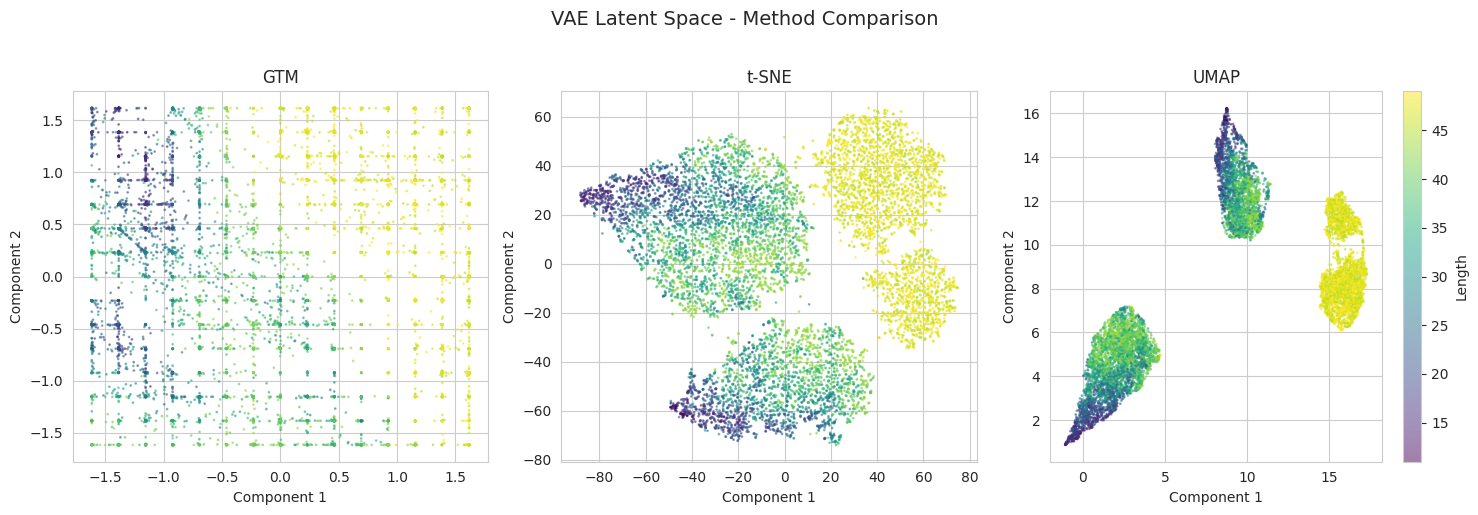

Saved comparison to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/method_comparison_vae.png


In [25]:
# Compare visualizations - VAE
n_cols = 3 if umap_available else 2
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

# GTM
axes[0].scatter(gtm_coords_vae[:, 0], gtm_coords_vae[:, 1], 
                c=df_vae.get('length', 'blue'), s=1, alpha=0.5, cmap='viridis')
axes[0].set_title('GTM')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')

# t-SNE
axes[1].scatter(tsne_vae[:, 0], tsne_vae[:, 1],
                c=df_vae.get('length', 'blue'), s=1, alpha=0.5, cmap='viridis')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

# UMAP
if umap_available:
    im = axes[2].scatter(umap_vae[:, 0], umap_vae[:, 1],
                        c=df_vae.get('length', 'blue'), s=1, alpha=0.5, cmap='viridis')
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('Component 1')
    axes[2].set_ylabel('Component 2')
    
    if 'length' in df_vae.columns:
        plt.colorbar(im, ax=axes[2], label='Length')

plt.suptitle('VAE Latent Space - Method Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'method_comparison_vae.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved comparison to {RESULTS_DIR / 'method_comparison_vae.png'}")

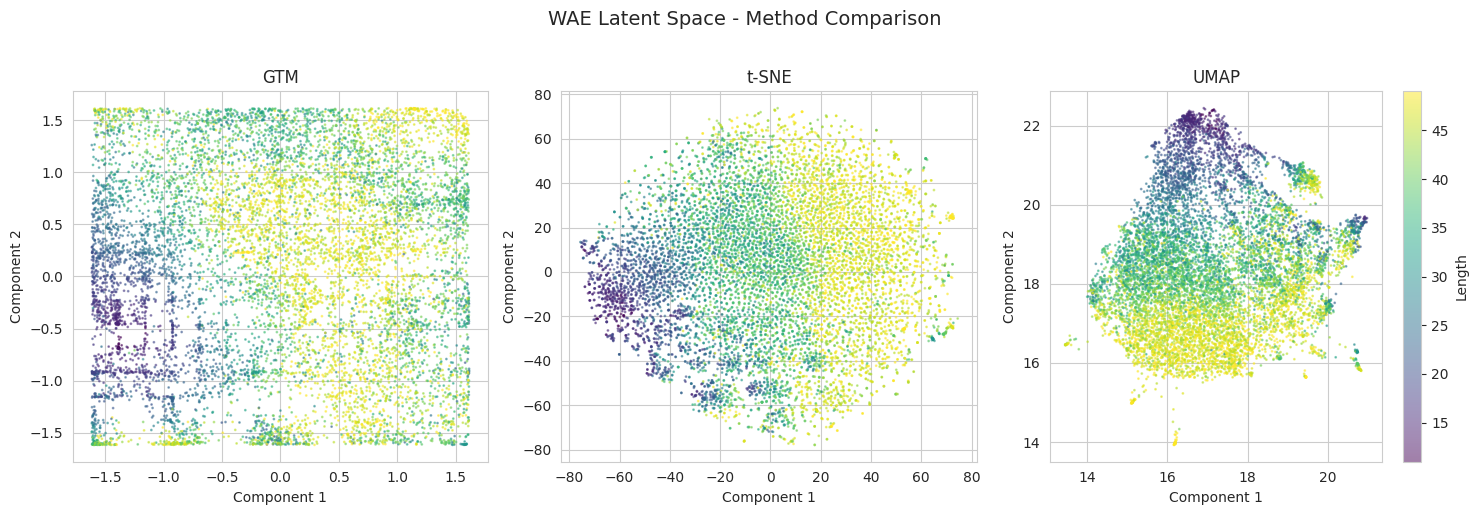

Saved comparison to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/method_comparison_wae.png


In [26]:
# Compare visualizations - WAE
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

# GTM
axes[0].scatter(gtm_coords_wae[:, 0], gtm_coords_wae[:, 1],
                c=df_wae.get('length', 'red'), s=1, alpha=0.5, cmap='viridis')
axes[0].set_title('GTM')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')

# t-SNE
axes[1].scatter(tsne_wae[:, 0], tsne_wae[:, 1],
                c=df_wae.get('length', 'red'), s=1, alpha=0.5, cmap='viridis')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')

# UMAP
if umap_available:
    im = axes[2].scatter(umap_wae[:, 0], umap_wae[:, 1],
                        c=df_wae.get('length', 'red'), s=1, alpha=0.5, cmap='viridis')
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('Component 1')
    axes[2].set_ylabel('Component 2')
    
    if 'length' in df_wae.columns:
        plt.colorbar(im, ax=axes[2], label='Length')

plt.suptitle('WAE Latent Space - Method Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'method_comparison_wae.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved comparison to {RESULTS_DIR / 'method_comparison_wae.png'}")

In [27]:
# Quantitative comparison
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def evaluate_embedding(embedding, n_clusters=10):
    """Evaluate embedding quality using clustering metrics."""
    # Perform clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embedding)
    
    # Compute silhouette score
    silhouette = silhouette_score(embedding, labels)
    
    return silhouette, labels

print("Evaluating embedding quality...\n")

# VAE embeddings
sil_gtm_vae, _ = evaluate_embedding(gtm_coords_vae)
sil_tsne_vae, _ = evaluate_embedding(tsne_vae)

print("VAE Embeddings:")
print(f"  GTM Silhouette Score: {sil_gtm_vae:.4f}")
print(f"  t-SNE Silhouette Score: {sil_tsne_vae:.4f}")

if umap_available:
    sil_umap_vae, _ = evaluate_embedding(umap_vae)
    print(f"  UMAP Silhouette Score: {sil_umap_vae:.4f}")

# WAE embeddings
sil_gtm_wae, _ = evaluate_embedding(gtm_coords_wae)
sil_tsne_wae, _ = evaluate_embedding(tsne_wae)

print("\nWAE Embeddings:")
print(f"  GTM Silhouette Score: {sil_gtm_wae:.4f}")
print(f"  t-SNE Silhouette Score: {sil_tsne_wae:.4f}")

if umap_available:
    sil_umap_wae, _ = evaluate_embedding(umap_wae)
    print(f"  UMAP Silhouette Score: {sil_umap_wae:.4f}")

Evaluating embedding quality...

VAE Embeddings:
  GTM Silhouette Score: 0.3758
  t-SNE Silhouette Score: 0.3988
  UMAP Silhouette Score: 0.4132

WAE Embeddings:
  GTM Silhouette Score: 0.3550
  t-SNE Silhouette Score: 0.3339
  UMAP Silhouette Score: 0.3547


## 8. Export Results

Save GTM models, figures, and region-specific samples.

In [28]:
# Save GTM models
import pickle

print("Saving GTM models...")

with open(RESULTS_DIR / 'gtm_vae_model.pkl', 'wb') as f:
    pickle.dump({
        'model': gtm_vae,
        'scaler': scaler_vae,
        'config': GTM_CONFIG
    }, f)

with open(RESULTS_DIR / 'gtm_wae_model.pkl', 'wb') as f:
    pickle.dump({
        'model': gtm_wae,
        'scaler': scaler_wae,
        'config': GTM_CONFIG
    }, f)

print(f"Saved GTM models to {RESULTS_DIR}")

Saving GTM models...
Saved GTM models to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis


In [29]:
# Save embeddings
print("Saving embeddings...")

# VAE embeddings
np.savez(
    RESULTS_DIR / 'embeddings_vae.npz',
    gtm=gtm_coords_vae,
    tsne=tsne_vae,
    umap=umap_vae if umap_available else None,
    latent=z_vae,
    responsibilities=responsibilities_vae
)

# WAE embeddings
np.savez(
    RESULTS_DIR / 'embeddings_wae.npz',
    gtm=gtm_coords_wae,
    tsne=tsne_wae,
    umap=umap_wae if umap_available else None,
    latent=z_wae,
    responsibilities=responsibilities_wae
)

print(f"Saved embeddings to {RESULTS_DIR}")

Saving embeddings...
Saved embeddings to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis


In [30]:
# Save DataFrames with all information
print("Saving analysis DataFrames...")

# Add all embeddings to DataFrames
df_vae['tsne_x'] = tsne_vae[:, 0]
df_vae['tsne_y'] = tsne_vae[:, 1]

df_wae['tsne_x'] = tsne_wae[:, 0]
df_wae['tsne_y'] = tsne_wae[:, 1]

if umap_available:
    df_vae['umap_x'] = umap_vae[:, 0]
    df_vae['umap_y'] = umap_vae[:, 1]
    df_wae['umap_x'] = umap_wae[:, 0]
    df_wae['umap_y'] = umap_wae[:, 1]

# Save to CSV
df_vae.to_csv(RESULTS_DIR / 'gtm_analysis_vae.csv', index=False)
df_wae.to_csv(RESULTS_DIR / 'gtm_analysis_wae.csv', index=False)

print(f"Saved DataFrames to {RESULTS_DIR}")

Saving analysis DataFrames...
Saved DataFrames to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis


In [31]:
# Save mode information
print("Saving mode information...")

modes_info = {
    'vae': {
        'coordinates': modes_vae.tolist(),
        'densities': densities_vae,
        'threshold': float(threshold_vae)
    },
    'wae': {
        'coordinates': modes_wae.tolist(),
        'densities': densities_wae,
        'threshold': float(threshold_wae)
    }
}

import json
with open(RESULTS_DIR / 'gtm_modes.json', 'w') as f:
    json.dump(modes_info, f, indent=2)

print(f"Saved mode information to {RESULTS_DIR / 'gtm_modes.json'}")

Saving mode information...
Saved mode information to /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis/gtm_modes.json


In [32]:
# Create summary report
summary = f"""
GTM Analysis Summary
====================

Configuration:
- Number of nodes: {GTM_CONFIG['num_nodes']}
- Number of basis functions: {GTM_CONFIG['num_basis_functions']}
- Regularization: {GTM_CONFIG['reg_coeff']}
- Basis width: {GTM_CONFIG['basis_width']}
- Maximum iterations: {GTM_CONFIG['max_iter']}

VAE Results:
- Dataset size: {len(z_vae)}
- Latent dimension: {z_vae.shape[1]}
- Average log-likelihood: {llhs_vae.mean().item():.4f}
- Number of modes: {len(modes_vae)}
- GTM Silhouette Score: {sil_gtm_vae:.4f}
- t-SNE Silhouette Score: {sil_tsne_vae:.4f}

WAE Results:
- Dataset size: {len(z_wae)}
- Latent dimension: {z_wae.shape[1]}
- Average log-likelihood: {llhs_wae.mean().item():.4f}
- Number of modes: {len(modes_wae)}
- GTM Silhouette Score: {sil_gtm_wae:.4f}
- t-SNE Silhouette Score: {sil_tsne_wae:.4f}

Output Files:
- GTM models: gtm_vae_model.pkl, gtm_wae_model.pkl
- Embeddings: embeddings_vae.npz, embeddings_wae.npz
- Analysis DataFrames: gtm_analysis_vae.csv, gtm_analysis_wae.csv
- Visualizations: *.png, *.html
- Mode information: gtm_modes.json

Results saved to: {RESULTS_DIR}
"""

with open(RESULTS_DIR / 'summary.txt', 'w') as f:
    f.write(summary)

print(summary)


GTM Analysis Summary

Configuration:
- Number of nodes: 225
- Number of basis functions: 100
- Regularization: 100
- Basis width: 1
- Maximum iterations: 200

VAE Results:
- Dataset size: 10000
- Latent dimension: 100
- Average log-likelihood: -82.8970
- Number of modes: 23
- GTM Silhouette Score: 0.3758
- t-SNE Silhouette Score: 0.3988

WAE Results:
- Dataset size: 10000
- Latent dimension: 100
- Average log-likelihood: -134.3624
- Number of modes: 23
- GTM Silhouette Score: 0.3550
- t-SNE Silhouette Score: 0.3339

Output Files:
- GTM models: gtm_vae_model.pkl, gtm_wae_model.pkl
- Embeddings: embeddings_vae.npz, embeddings_wae.npz
- Analysis DataFrames: gtm_analysis_vae.csv, gtm_analysis_wae.csv
- Visualizations: *.png, *.html
- Mode information: gtm_modes.json

Results saved to: /data/aorlov/Programs/WAE_peptides/output/sampling_analysis/gtm_analysis



## Summary

This notebook implemented a comprehensive GTM analysis workflow:

1. **Setup**: Loaded VAE and WAE models with their trained latent representations
2. **Data Preparation**: Extracted and standardized latent vectors from both models
3. **GTM Training**: Trained GTM models with 225 nodes and 100 basis functions
4. **Visualization**: Created interactive 2D projections colored by peptide properties
5. **Landscape Analysis**: Identified modes, analyzed density patterns and responsibilities
6. **Region Sampling**: Implemented functions to generate peptides from specific GTM regions
7. **Comparison**: Compared GTM with t-SNE and UMAP using silhouette scores
8. **Export**: Saved models, embeddings, figures, and analysis results

Key findings:
- GTM provides smooth, interpretable 2D projections of high-dimensional latent spaces
- Density maps reveal structure and clustering in the peptide space
- Responsibility analysis shows how well-defined the mapping is
- Comparison with t-SNE and UMAP helps validate the embedding quality

All results have been saved to the results directory for further analysis.